In [2]:
import sys
print(sys.executable)


/home/saiful-islam-rakib/anaconda3/bin/python


In [3]:
%pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.8/620.8 MB 29.2 MB/s  0:00:21m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 24.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 28.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 30.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 32.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 31.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16/16 [tensorflow]6 [tensorflow]]data-server]
Note: you may need to restart the kernel to use updated packages.


In [4]:
import tensorflow as tf
print(tf.__version__)


2026-01-06 23:17:53.862291: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-06 23:17:54.228813: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-06 23:17:56.534916: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/saiful-islam-rakib/anaconda3/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


2.20.0


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

import os
import random
import numpy as np
import matplotlib.pyplot as plt

# ignore information messgaes from tensorflow, but we will receieve error messages
os.environ['TFF_CPP_MIN_LOG_LEVEL'] = '2'

%matplotlib inline

In [6]:
gpus = tf.config.experimental.list_physical_devices('GPU')
print("Number of GPU =", len(gpus))

if len(gpus) > 0:
    tf.config.experimental.set_memory_growth(gpus[0], True)
else:
    print("No GPU found. Using CPU.")


Number of GPU = 0
No GPU found. Using CPU.


2026-01-06 23:18:16.060947: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(f"Shape of x_train: {x_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print()
print(f"Shape of x_test: {x_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Shape of x_train: (60000, 28, 28)
Shape of y_train: (60000,)

Shape of x_test: (10000, 28, 28)
Shape of y_test: (10000,)


Image (#9): Which is digit '4'


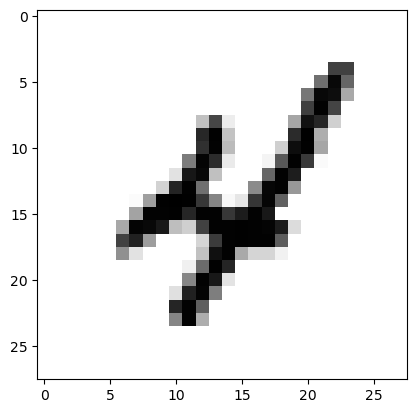

In [8]:
digit = 9
a = x_train[digit]
plt.imshow(a, cmap='gray_r')
print(f"Image (#{digit}): Which is digit '{y_train[digit]}'")

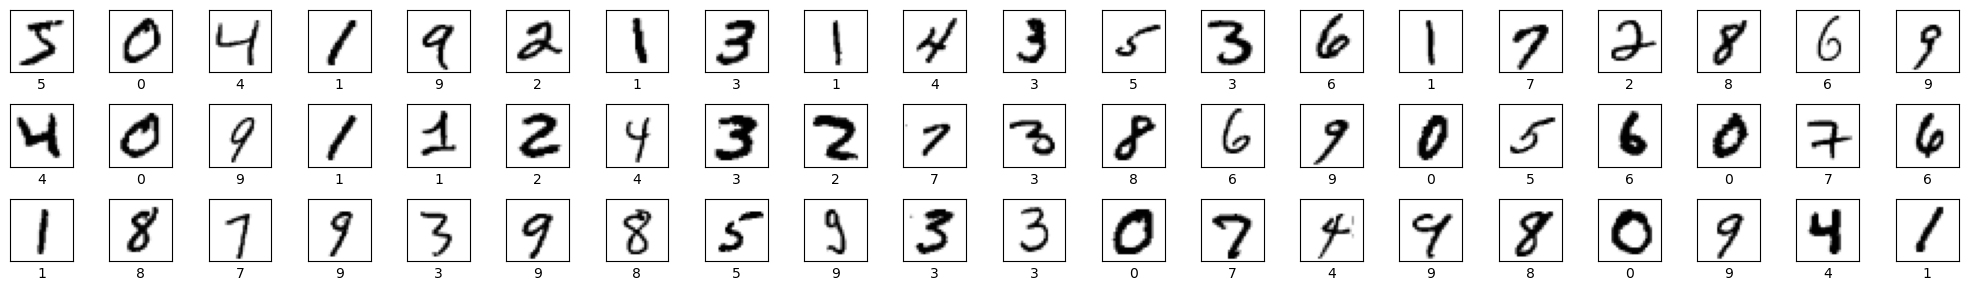

In [9]:
ROWS = 3
COLS = 20
i = 0

plt.figure(figsize=(20,3))
for r in range(ROWS):
    for c in range(COLS):
        plt.subplot(ROWS, COLS, i+1)
        plt.imshow(x_train[i], cmap=plt.cm.gray_r)
        
        plt.xticks([])
        plt.yticks([])
        plt.xlabel(y_train[i])
        i += 1
plt.tight_layout()
plt.show() 

In [10]:
x_train = x_train.reshape(-1, 28*28).astype("float32") / 255.0
x_test = x_test.reshape(-1, 28*28).astype("float32") / 255.0

Image (#9): Which is digit '4'


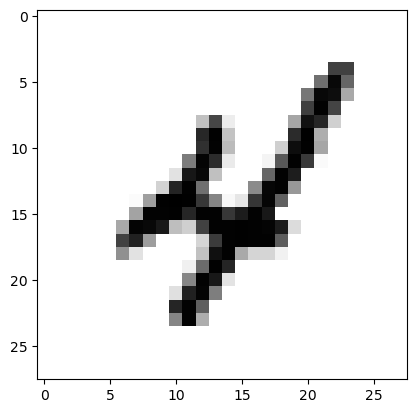

In [11]:
digit = 9 # Change to choose new digit
a = x_train[digit].reshape(28,28)
plt.imshow(a, cmap='gray_r')
print(f"Image (#{digit}): Which is digit '{y_train[digit]}'")

In [12]:
model = keras.Sequential([
    keras.Input(shape=(28*28,)),
    layers.Dense(units=256, activation='relu'),
    layers.Dense(units=128, activation='relu'),
    layers.Dense(units=10, activation='softmax')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [14]:
h = model.fit(x=x_train, y=y_train, epochs=5, batch_size=64, validation_split=0.3)

Epoch 1/5


2026-01-06 23:19:38.614827: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 131712000 exceeds 10% of free system memory.


655/657 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8641 - loss: 0.4680

2026-01-06 23:19:42.141130: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 56448000 exceeds 10% of free system memory.


657/657 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9236 - loss: 0.2600 - val_accuracy: 0.9561 - val_loss: 0.1472
Epoch 2/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9687 - loss: 0.1050 - val_accuracy: 0.9655 - val_loss: 0.1094
Epoch 3/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9794 - loss: 0.0660 - val_accuracy: 0.9669 - val_loss: 0.1076
Epoch 4/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9861 - loss: 0.0445 - val_accuracy: 0.9706 - val_loss: 0.1045
Epoch 5/5
657/657 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9894 - loss: 0.0322 - val_accuracy: 0.9686 - val_loss: 0.1120


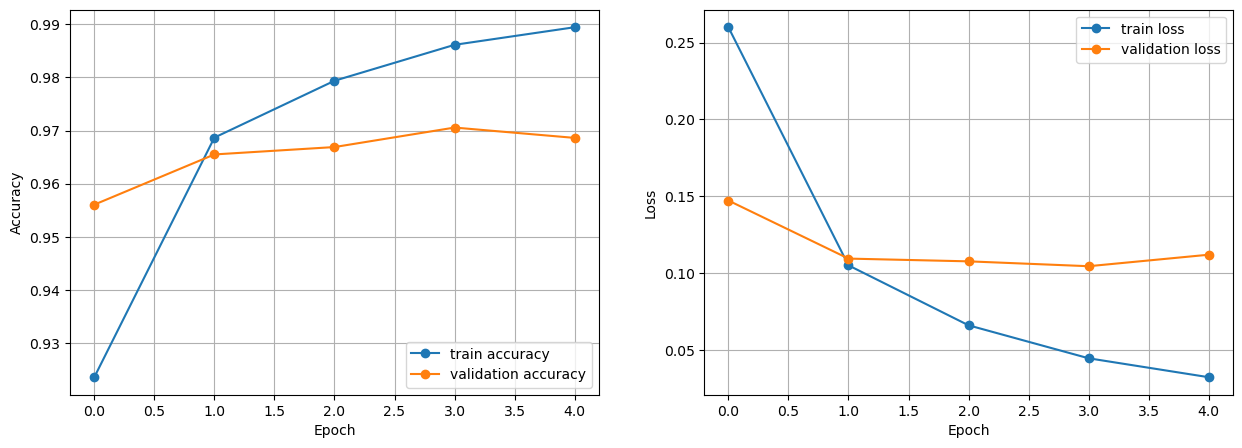

In [17]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
plt.plot(h.history['accuracy'], 'o-', label='train accuracy')
plt.plot(h.history['val_accuracy'], 'o-', label = 'validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend(loc='lower right')

plt.subplot(1,2,2)
plt.plot(h.history['loss'], 'o-', label='train loss')
plt.plot(h.history['val_loss'], 'o-', label='validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend(loc='upper right')

plt.show()


In [18]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print('\nTest accuracy:', test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1098

Test accuracy: 0.9674000144004822


In [19]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


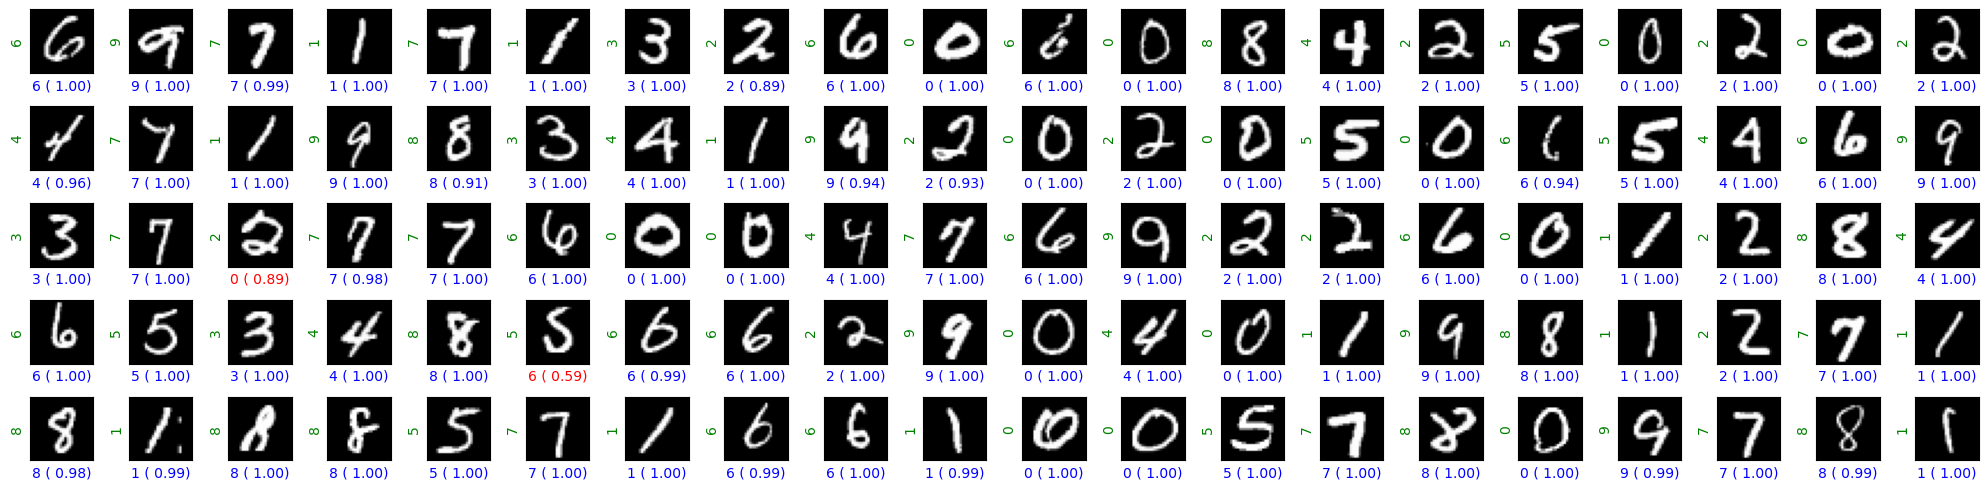

In [20]:
ROWS = 5
COLS = 20

random_indices = random.sample(range(x_test.shape[0]), ROWS*COLS)
sample_images = x_test[random_indices, :]
sample_labels = y_test[random_indices]
predictions = model.predict(sample_images)

i = 0

plt.figure(figsize=(20,5))
for r in range(ROWS):
    for c in range(COLS):
        plt.subplot(ROWS, COLS, i+1)
        plt.imshow(sample_images[i].reshape(28,28), cmap=plt.cm.gray)
        plt.xticks([])
        plt.yticks([])
        prediction = np.argmax(predictions[i]) 
        confidence = predictions[i][prediction]
        if sample_labels[i] == prediction:
            plt.xlabel(f"{prediction} ({confidence: .2f})", color='b')
        else:
            plt.xlabel(f"{prediction} ({confidence: .2f})", color='r')
        plt.ylabel(sample_labels[i], color='g')
        i += 1
        
plt.tight_layout()
plt.show()

In [21]:
def test(i):
    img = x_test[i]
    predictions = model.predict([img.reshape(-1,784)])

    plt.figure()
    plt.imshow(img.reshape(28,28), cmap='gray_r')
    plt.xticks([])
    plt.yticks([])

    plt.ylabel(f"True Label: {y_test[i]}", color='g') # ground truth

    prediction = np.argmax(predictions) 
    confidence = predictions[0][prediction]

    if y_test[i] == prediction:
        plt.xlabel(f"prediction = {prediction} (Confidence Score = {confidence: .2f})", color='b')
    else:
        plt.xlabel(f"prediction = {prediction} (Confidence Score = {confidence: .2f})", color='r')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


/home/saiful-islam-rakib/anaconda3/lib/python3.13/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=('Tensor(shape=(1, 784))',)
  warnings.warn(msg)


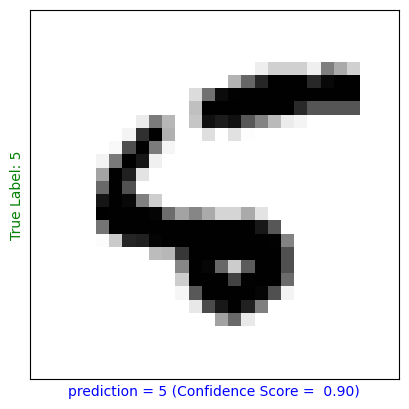

In [22]:
test(8)

In [23]:
%pip install opencv-python


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 30.1 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.5/16.5 MB 36.6 MB/s  0:00:00 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]0m [opencv-python]
Note: you may need to restart the kernel to use updated packages.


In [24]:
import cv2
print(cv2.__version__)


4.12.0


In [25]:
# Webcam digit recognition using your trained MNIST model
# Press 'q' to quit

import cv2
import numpy as np

def preprocess_for_mnist(roi_bgr):
    """
    Take a BGR ROI from webcam and convert to MNIST-like (1, 784) float32 array in [0,1].
    Returns (x_input, debug_threshold_image) or (None, debug_threshold_image) if no digit found.
    """
    # 1) Convert to grayscale
    gray = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # 2) Threshold: make digit WHITE on BLACK background (MNIST-like)
    th = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        11, 2
    )

    # 3) Find contours (digit candidates)
    cnts, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return None, th

    # Take biggest contour = most likely the digit
    c = max(cnts, key=cv2.contourArea)
    area = cv2.contourArea(c)
    if area < 80:  # too small -> probably noise
        return None, th

    x, y, w, h = cv2.boundingRect(c)
    digit = th[y:y+h, x:x+w]

    # 4) Make it square by padding, then resize to 28x28
    size = max(w, h)
    pad_x = (size - w) // 2
    pad_y = (size - h) // 2
    digit = cv2.copyMakeBorder(
        digit,
        pad_y, size - h - pad_y,
        pad_x, size - w - pad_x,
        cv2.BORDER_CONSTANT, value=0
    )
    digit = cv2.resize(digit, (28, 28), interpolation=cv2.INTER_AREA)

    # 5) Normalize to [0,1] and flatten to (1,784)
    x_input = digit.astype("float32") / 255.0
    x_input = x_input.reshape(1, 784)
    return x_input, th


# ---------- MAIN WEBCAM LOOP ----------
cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Camera not found. Try changing VideoCapture(0) to (1) or check permissions.")

print("Webcam started. Put your paper digit inside the BLUE box. Press 'q' to quit.")

while True:
    ok, frame = cap.read()
    if not ok:
        break

    H, W = frame.shape[:2]

    # Blue box ROI where you will show the digit (you can adjust if you want)
    x1, y1 = int(W * 0.55), int(H * 0.20)
    x2, y2 = int(W * 0.95), int(H * 0.60)

    roi = frame[y1:y2, x1:x2].copy()

    x_input, th = preprocess_for_mnist(roi)

    pred_text = "No digit"
    if x_input is not None:
        probs = model.predict(x_input, verbose=0)[0]   # (10,)
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))
        pred_text = f"{pred}  (conf={conf:.2f})"

    # Draw ROI rectangle and prediction text
    cv2.rectangle(frame, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(frame, "Show digit inside BLUE box", (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    cv2.putText(frame, f"Pred: {pred_text}", (10, 65),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 0, 255), 2)

    # Show camera
    cv2.imshow("MNIST Webcam Digit", frame)

    # OPTIONAL: show threshold debug window (helps if detection fails)
    cv2.imshow("Threshold (debug)", th)

    # Quit
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


Webcam started. Put your paper digit inside the BLUE box. Press 'q' to quit.


QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is not the object's thread (0x3a50c9a0).
Cannot move to target thread (0x38121730)

QObject::moveToThread: Current thread (0x38121730) is n